### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she eats at a restaurant with average expense between \\$20 to \\$50 : 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [887]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Problems

Use the prompts below to get started with your data analysis.  

### 1. Read in the `coupons.csv` file.




In [888]:
data = pd.read_csv('data/coupons.csv')

In [889]:
data.head(5)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


### 2. Investigate the dataset for missing or problematic data.

#### a. Verify duplicates

In [890]:
data.duplicated().sum()

74

In [891]:
#Compare the duplicate rows
data_dups = data[ data.duplicated(keep=False)]
data_dups.head(6)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
4191,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4235,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4279,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1


#### b. Verify data unique values on some columns using unique() and spot check values

In [892]:
#Verify destination values
data["destination"].unique()

array(['No Urgent Place', 'Home', 'Work'], dtype=object)

In [893]:
#Verify weather 
data["weather"].unique()

array(['Sunny', 'Rainy', 'Snowy'], dtype=object)

In [894]:
#Verify coupon 
data["coupon"].unique()

array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar',
       'Restaurant(20-50)'], dtype=object)

In [895]:
#Verify marital status
data["maritalStatus"].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [896]:
#Verify coffee house
data["CoffeeHouse"].unique()

array(['never', 'less1', '4~8', '1~3', 'gt8', nan], dtype=object)

In [897]:
#Verify restaurant
data["Restaurant20To50"].unique()

array(['1~3', 'less1', 'never', 'gt8', '4~8', nan], dtype=object)

#### c. Verify column names and types
- use data.dtypes or data.columns

In [898]:
#Check column types 
data.dtypes

destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object

#### d. Verify data counts

In [899]:
#Check coupon counts
data["coupon"].value_counts() 

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64

In [900]:
#Check Y counts
data["Y"].value_counts()

Y
1    7210
0    5474
Name: count, dtype: int64

In [901]:
#Get data stats
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


#### e. Verify missing values

In [902]:
#Change missing value using isnull()
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

<Axes: >

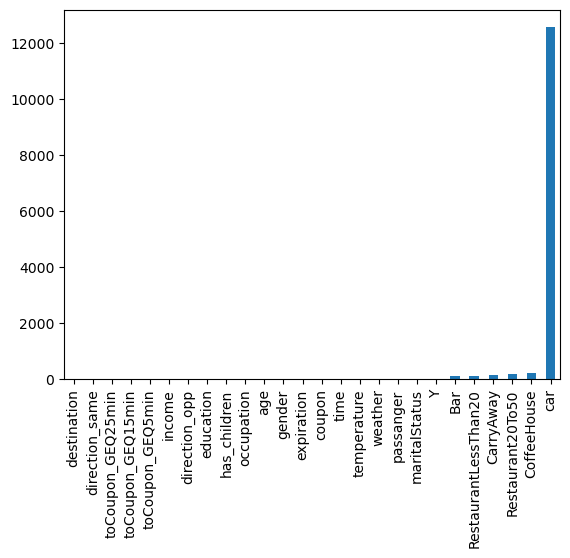

In [903]:
#Plot the missing values
data.isnull().sum().sort_values().plot.bar()

#### f. Verify and spot check missing value counts 

In [904]:
data["Bar"].isnull().value_counts()  

Bar
False    12577
True       107
Name: count, dtype: int64

In [905]:

data["CoffeeHouse"].isnull().value_counts()

CoffeeHouse
False    12467
True       217
Name: count, dtype: int64

In [906]:
data["car"].isnull().value_counts()

car
True     12576
False      108
Name: count, dtype: int64

---

### 3. Decide what to do about your missing data -- drop, replace, other...

#### a. Rename columns and save it into a new clean_data dataframe

In [907]:
#Rename columns for typo, readability and case consistency and save it to a clean dataframe
clean_data = data.rename(columns = {"passanger": "passenger",
                       "maritalStatus": "marital_status",
                       "Bar":"bar", 
                       "CoffeeHouse":"coffee_house",
                       "CarryAway":"carry_away",
                       "RestaurantLessThan20":"restaurant_lessthan20", 
                       "Restaurant20To50":"restaurant_20to50"
                        }) 



#### b. Drop duplicates rows  - 74 rows

In [908]:
#Drop duplicate rows
#Original data shape is 12684.Use clean_data.duplicated().sum()
clean_data = clean_data.drop_duplicates()


In [909]:
#Verify clean_data if duplicates are removed. Should be equal to zero
clean_data.duplicated().sum()

0

In [910]:
#Compare original to new data shape
print("Original shape:  %d" %data.shape[0])
print("New shape: %d" %clean_data.shape[0]) 

Original shape:  12684
New shape: 12610


#### c. Clean 'age' column

In [911]:
#Check age values
clean_data['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [912]:
#Replace strings 'below21' to 20 and '50plus' to 51 and then convert to int
clean_data["age"] = clean_data["age"].str.replace("below21", "20") 
clean_data["age"] = clean_data["age"].str.replace("50plus", "51")

#Convert the 'age' column from string/object to integer
clean_data['age'] = clean_data['age'].astype(int)

In [913]:
#Verify new age values
clean_data['age'].unique()

array([21, 46, 26, 31, 41, 51, 36, 20])

#### d. Drop the 'car' column since most are null values and it is not used in calculations

In [914]:
#Drop the car column
clean_data = clean_data.drop(columns=['car'])

#### e. Clean values of these columns: bar, restaurant_lessthan20, carry_away, restaurant_20to50, coffee_house and convert to numeric   
Replace values to: never = 0, less1 = 0, 1\~3 = 3, gt8 = 9, 4\~8 = 8


In [915]:
#List of columns to replace
column_names = ['bar', 'coffee_house', 'carry_away', 'restaurant_lessthan20', 'restaurant_20to50']

#Value dictionary
value_dict= { 'never':'0', 'less1':'0', '1~3':'3', 'gt8':'9', '4~8': '8'} 

#clean_data['bar'] = clean_data['bar'].replace(value_list)

#Use for loop to replace values in these columns
for col in column_names:
    #Replace data to new values
    clean_data[col] = clean_data[col].replace(value_dict)
    
    #Convert string object to numeric
    clean_data[col] = pd.to_numeric(clean_data[col])


#### f. Clean 'income' column and transform into 2 new income columns

In [916]:
#Check income values
clean_data['income'].unique()

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [917]:
#Replace income with words to actual numerical value
clean_data["income"] = clean_data["income"].str.replace('$100000 or More', '$100000 - $112499', regex=False) 
clean_data["income"] = clean_data["income"].str.replace('Less than $12500', '$500 - $12499', regex=False)

#Replace '$' with empty string
clean_data["income"] = clean_data["income"].str.replace('$', '', regex=False) 

#Split income to create new low - high income columns
temp_income_split = clean_data["income"].str.split(' - ', expand=True)


# Create 2 new income columns and assigned as integer
clean_data['income_low_range'] = temp_income_split[0].astype(int)
clean_data['income_high_range'] = temp_income_split[1].astype(int)



In [918]:
#Verify new income low range column 
clean_data["income_low_range"].unique()

array([ 37500,  62500,  12500,  75000,  50000,  25000, 100000,  87500,
          500])

#### g. Verify cleaned data and converted columns

In [919]:
clean_data['bar'].unique()

array([ 0.,  3.,  9., nan,  8.])

In [920]:
clean_data['restaurant_lessthan20'].unique()

array([ 8.,  3.,  0.,  9., nan])

In [921]:
clean_data.dtypes

destination               object
passenger                 object
weather                   object
temperature                int64
time                      object
coupon                    object
expiration                object
gender                    object
age                        int32
marital_status            object
has_children               int64
education                 object
occupation                object
income                    object
bar                      float64
coffee_house             float64
carry_away               float64
restaurant_lessthan20    float64
restaurant_20to50        float64
toCoupon_GEQ5min           int64
toCoupon_GEQ15min          int64
toCoupon_GEQ25min          int64
direction_same             int64
direction_opp              int64
Y                          int64
income_low_range           int32
income_high_range          int32
dtype: object

In [922]:
#Display cleaned data after replacement and transformations
clean_data

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,marital_status,...,restaurant_lessthan20,restaurant_20to50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,income_low_range,income_high_range
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,8.0,3.0,1,0,0,0,1,1,37500,49999
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,0,0,0,1,0,37500,49999
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,1,37500,49999
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,0,37500,49999
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,0,37500,49999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,8.0,3.0,1,0,0,1,0,1,75000,87499
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,8.0,3.0,1,0,0,0,1,1,75000,87499
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,8.0,3.0,1,0,0,1,0,0,75000,87499
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,8.0,3.0,1,1,1,0,1,0,75000,87499


---

### 4. What proportion of the total observations chose to accept the coupon?



In [923]:
#Get the total count who accepted the coupon with value 1
#Another way: yes_accepted_coupon = clean_data['Y'].value_counts().sort_values(ascending=False).iloc[0]
yes_accepted_coupons = clean_data.query("Y == 1").shape[0]
yes_accepted_coupons

7157

In [924]:
#Get the shape or total rows of the 'Y' column using .shape[0]
y_total = clean_data['Y'].shape[0]
y_total

12610

In [925]:
#Divide the yes accepted coupons with the total rows to get the proportion
accept_proportion =  yes_accepted_coupons / y_total
round(accept_proportion,2)    #accept_proportion.round(decimals=2)


0.57

#### Answer: The proportion of customer who accepted the coupon is 0.57

---

### 5. Use a bar plot to visualize the `coupon` column.

In [926]:
#Get the counts in the coupon column
coupon_data  =  clean_data["coupon"].value_counts()
coupon_data

coupon
Coffee House             3989
Restaurant(<20)          2779
Carry out & Take away    2344
Bar                      2010
Restaurant(20-50)        1488
Name: count, dtype: int64

Text(0, 0.5, 'Coupon Counts')

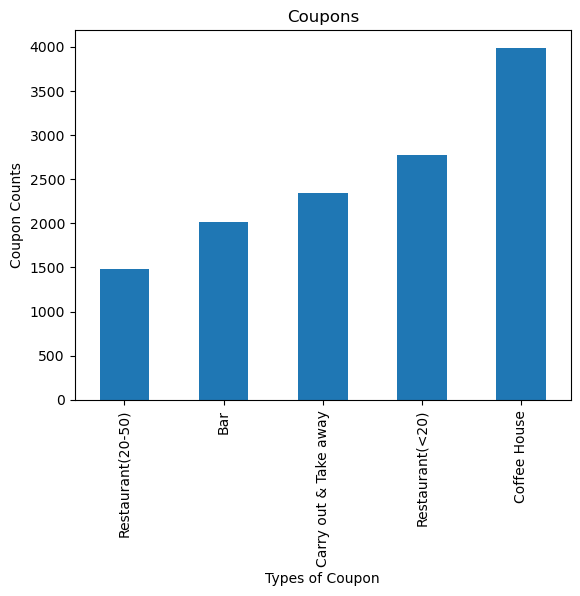

In [927]:
#Bar plot for the coupon column
clean_data["coupon"].value_counts().sort_values().plot(kind = 'bar')

# Add title and lbels
plt.title("Coupons")
plt.xlabel("Types of Coupon")
plt.ylabel("Coupon Counts")


---

#### 6. Use a histogram to visualize the temperature column.

Text(0, 0.5, 'Count')

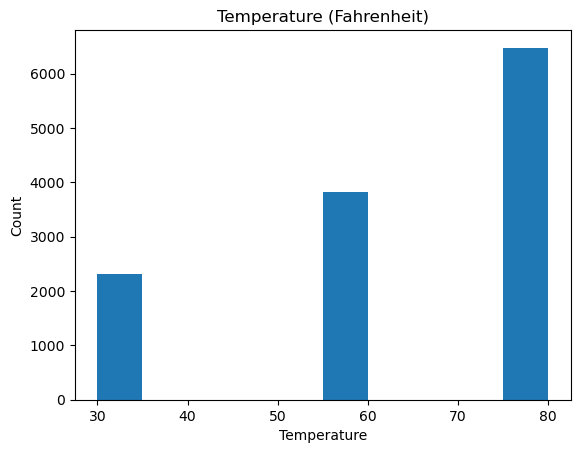

In [928]:
#Pyplot histogram for temperature
plt.hist(clean_data["temperature"])
plt.title("Temperature (Fahrenheit)")
plt.xlabel("Temperature")
plt.ylabel("Count")

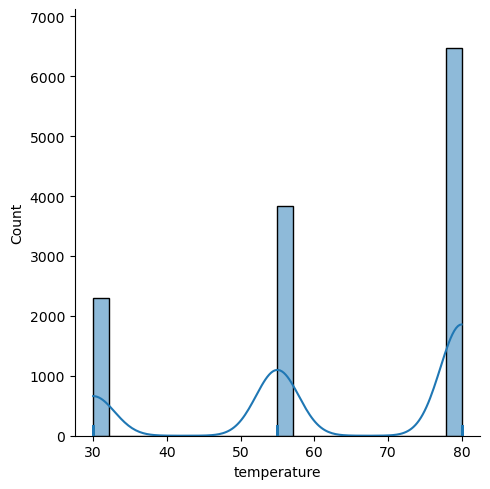

In [929]:
#Histogram using Seaborn with KDE and rug
sns.displot(clean_data["temperature"], kde = True, rug = True)

---

# **Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

#### 1. Create a new `DataFrame` that contains just the bar coupons.


In [930]:
bar_coupons_data = clean_data[clean_data["coupon"].str.contains("Bar")]
bar_coupons_data.head(5)

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,marital_status,...,restaurant_lessthan20,restaurant_20to50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,income_low_range,income_high_range
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,0,37500,49999
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,8.0,3.0,1,0,0,1,0,1,37500,49999
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,8.0,3.0,1,1,1,0,1,0,37500,49999
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,8.0,0.0,1,0,0,0,1,1,62500,74999
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,8.0,0.0,1,0,0,1,0,1,62500,74999


In [931]:
#Show bar coupon info
bar_coupons_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2010 entries, 9 to 12682
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   destination            2010 non-null   object 
 1   passenger              2010 non-null   object 
 2   weather                2010 non-null   object 
 3   temperature            2010 non-null   int64  
 4   time                   2010 non-null   object 
 5   coupon                 2010 non-null   object 
 6   expiration             2010 non-null   object 
 7   gender                 2010 non-null   object 
 8   age                    2010 non-null   int32  
 9   marital_status         2010 non-null   object 
 10  has_children           2010 non-null   int64  
 11  education              2010 non-null   object 
 12  occupation             2010 non-null   object 
 13  income                 2010 non-null   object 
 14  bar                    1989 non-null   float64
 15  coffee_h

#### 2. What proportion of bar coupons were accepted?


In [932]:
#Get the shape(total rows) of the bar coupon dataframe
bar_coupons_total = bar_coupons_data.shape[0]
bar_coupons_total

2010

In [933]:
#Review the counts on the bar coupon data 'Y' column
bar_coupons_data['Y'].value_counts()

Y
0    1186
1     824
Name: count, dtype: int64

In [934]:
#Get the count who accepted coupons in the bar coupons
yes_accepted_bar_coupons = bar_coupons_data.query("Y == 1").shape[0]
yes_accepted_bar_coupons

824

In [935]:
#Calculate the proportion of the accepted bar coupons
accepted_bar_coupons_prop = yes_accepted_bar_coupons / bar_coupons_total
round(accepted_bar_coupons_prop,2) 


0.41

#### Answer: The proportion is 0.41 for the accepted bar coupons.

Text(0.5, 9.444444444444438, 'No = 0 | Yes = 1')

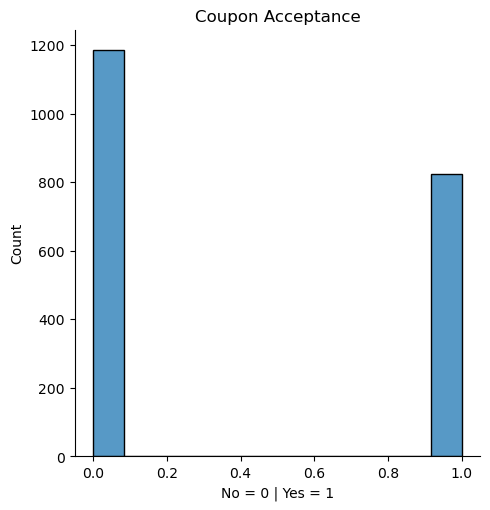

In [936]:
#Seaborn histogram
sns.displot(bar_coupons_data, x = 'Y')
plt.title("Coupon Acceptance")
plt.xlabel("No = 0 | Yes = 1")

---

#### 3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [937]:
#Review bar data
bar_coupons_data['bar'].unique()

array([ 0.,  3.,  9., nan,  8.])

In [938]:
#Get the count of drivers who accepted the coupon and who went to a bar 3 or fewer times a month
driver_bar_3orless = bar_coupons_data.query("Y == 1 and bar <= 3").shape[0]
driver_bar_3orless


663

In [939]:
#Get the count of drivers who accepted the coupon and who went to the bar more than 3 a month
driver_bar_over3 = bar_coupons_data.query("Y == 1 and bar > 3").shape[0]
driver_bar_over3

153

In [940]:
#Calculate rate of acceptance from the total

#Drivers who goes 3 or less
rate_driver_bar_3orless  = driver_bar_3orless / bar_coupons_total * 100
rate_driver_bar_3orless = round(rate_driver_bar_3orless, 2)
rate_driver_bar_3orless

32.99

In [941]:
#Drivers who goes 3 or less
rate_driver_bar_over3 = driver_bar_over3 / bar_coupons_total * 100
rate_driver_bar_over3 = round(rate_driver_bar_over3, 2)
rate_driver_bar_over3

7.61

#### Answer:
- The acceptance rate of drivers who goes 3 or less in bar a month is 32.99%.  It is more likely that they will accept the coupon compared to drivers who goes more than 3 in the bar a month.
- The acceptance rate of drivers who goes more than 3 in a bar a month is 7.61%. They are more likely not to accept the coupon compared to drivers who goes less in the bar.
- The difference of rate is about 25.38%. ie.( 32.99% - 7.61%)

#### 4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [942]:
#Drivers count who goes more than once and over 25 age
driver_bar_more1_over25 = bar_coupons_data.query("Y == 1 and bar > 1 and age > 25")
driver_bar_more1_over25_count = driver_bar_more1_over25.shape[0]
driver_bar_more1_over25_count

292

In [943]:
#Drivers count who goes once and 25 or less in age
driver_bar_1_25orunder = bar_coupons_data.query("Y == 1 and bar <= 1 and age <= 25")
driver_bar_1_25orunder_count = driver_bar_1_25orunder.shape[0]
driver_bar_1_25orunder_count

129

In [944]:
#Calculabsate rate of acceptance and print format in percentage

#Drivers over 25
rate_driver_bar_more1_over25 = driver_bar_more1_over25_count  / bar_coupons_total * 100
print(f"Drivers over 25: {rate_driver_bar_more1_over25:.2f}%")


#Drivers 25 or under
rate_driver_bar_1_25orunder = driver_bar_1_25orunder_count  / bar_coupons_total * 100
print(f"Drivers 25 or under: {rate_driver_bar_1_25orunder:.2f}%")


Drivers over 25: 14.53%
Drivers 25 or under: 6.42%


#### Answer:
- The acceptance rate of drivers over 25 of age is 14.53%, and the acceptance rate of drivers 25 or under of age is 6.42%.
- It is more likely drivers over 25 of age accepts the coupon compared to those drivers 25 and under of age.
- Drivers population over 25 who accepted the coupon is more than twice the drivers 25 of age or under.

#### 5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [945]:
#Review passenger
bar_coupons_data['passenger'].unique()

#Note Not 'Kid(s)'

array(['Kid(s)', 'Alone', 'Friend(s)', 'Partner'], dtype=object)

In [946]:
#Review occupation
bar_coupons_data['occupation'].unique()

#Note: Not 'Farming Fishing & Forestry'

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [947]:
#Drivers who goes more than once and passenger not 'Kid(s)' and occupation not 'Farming Fishing & Forestry'

driver_nokids_nofarm_df = bar_coupons_data.query("Y == 1 and bar > 1 and passenger != 'Kid(s)' and occupation != 'Farming Fishing & Forestry' ")
driver_selected_columns = ['coupon','bar','Y','passenger','occupation']
driver_nokids_nofarm_df[driver_selected_columns]


,coupon,bar,Y,passenger,occupation
90,Bar,3.0,1,Friend(s),Student
101,Bar,3.0,1,Alone,Student
112,Bar,3.0,1,Friend(s),Student
123,Bar,3.0,1,Alone,Student
127,Bar,3.0,1,Alone,Student
...,...,...,...,...,...
12482,Bar,3.0,1,Friend(s),Office & Administrative Support
12485,Bar,3.0,1,Alone,Office & Administrative Support
12488,Bar,3.0,1,Partner,Office & Administrative Support
12525,Bar,3.0,1,Friend(s),Food Preparation & Serving Related


In [948]:
#Get the count for driver_nokids_nofarm_count
driver_nokids_nofarm_count = driver_nokids_nofarm_df.shape[0]
driver_nokids_nofarm_count

393

In [949]:
#Calculate the acceptance rate for drivers no kids passenger and no farm  job

rate_driver_nokids_nofarm = driver_nokids_nofarm_count  / bar_coupons_total * 100
print(f"Acceptance rate: {rate_driver_nokids_nofarm:.2f}%")


Acceptance rate: 19.55%


In [950]:
#Drivers who goes more than once and passenger has 'Kid(s)' and occupation is 'Farming Fishing & Forestry'

driver_kids_farm_df = bar_coupons_data.query("Y == 1 and bar > 1  and passenger == 'Kid(s)' and occupation == 'Farming Fishing & Forestry' ")
driver_selected_columns = ['coupon','bar','Y','passenger','occupation']
driver_kids_farm_df[driver_selected_columns]    #No result

#Get the count for driver_kids_farm_df
driver_kids_farm_df.shape[0]

0

#### Answer: 
- The acceptance rate of drivers who has no kid passengers and no farming related job is 19.55%.
- There are no data for drivers who goes more than once to the bar and has 'Kid(s)' passengers and occupation is 'Farming Fishing & Forestry', thus no comparison.

#### 6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



- **Drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed**

In [951]:
#Review marital_status - 'Widowed'
bar_coupons_data['marital_status'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [952]:
#Drivers had passengers that were not a kid, and were not widowed
driver_nokids_nowidowed = bar_coupons_data.query("Y == 1 and bar > 1 and passenger != 'Kid(s)' and marital_status != 'Widowed'").shape[0]
driver_nokids_nowidowed

393

In [953]:
#Calculate the acceptance rate for driver_nokids_nowidowed

rate_driver_nokids_nowidowed = driver_nokids_nowidowed / bar_coupons_total * 100
print(f"Acceptance rate: is {rate_driver_nokids_nowidowed:.2f}%")

Acceptance rate: is 19.55%


- **Drivers who go to bars more than once a month and are under the age of 30** 

In [954]:
#Drivers who had passengers that were not a kid, and were not widowed
driver_under30 = bar_coupons_data.query("Y == 1 and bar > 1 and age < 30").shape[0]
driver_under30

249

In [955]:
#Calculate the acceptance rate for driver_under30

rate_driver_under30 = driver_under30 / bar_coupons_total * 100
print(f"Acceptance rate: is {rate_driver_under30:.2f}%")

Acceptance rate: is 12.39%


- **Drivers who go to cheap restaurants more than 4 times a month and income is less than 50K**

In [956]:
#Review income
bar_coupons_data['income'].unique()

array(['37500 - 49999', '62500 - 74999', '12500 - 24999', '75000 - 87499',
       '50000 - 62499', '25000 - 37499', '100000 - 112499',
       '87500 - 99999', '500 - 12499'], dtype=object)

-- **Note:  'income' column has been transformed into 2 new columns: 'income_low_range' and 'income_high_range' in the data cleaning process**

In [957]:
#Drivers who go to cheap restaurants more than 4 times a month and income is less than 50K
driver_restaurantless_under50k = bar_coupons_data.query("Y == 1 and restaurant_lessthan20 > 4 and income_low_range < 50000").shape[0]
driver_restaurantless_under50k

156

In [958]:
#Calculate the acceptance rate for driver_restaurantless_under50k

rate_driver_restaurantless_under50k = driver_restaurantless_under50k / bar_coupons_total * 100
print(f"Acceptance rate: {rate_driver_restaurantless_under50k:.2f}%")

Acceptance rate: 7.76%


#### Answer: 
- Acceptance rate for drivers with no kids passenger and is not widowed is 19.55%
- Acceptance rate for drivers under the age of 30 is 12.39%
- Acceptance rate for drivers who go in cheap restaurant and makes under 50k is 7.76%
- To conclude, drivers who has no kid passengers and is not widowed has the highest rate who accepts the coupon, and drivers who go in a cheap restaurant and makes less than 50k income has the lowest acceptance rate in comparison to these population group. 

#### 7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

- Drivers who go 3 times or less a month in a bar is more likely to accept the coupons compared to drivers who go frequently more than 3 times a month to the bar.
- Drivers who go to bars more than once a month and who is over 25 years old is more likely to accept the coupons compared to drivers who is 25 years old or under.  
- Drivers who go to bars more than once a month and has no 'kid' passengers and no farming/fishing/forestry related occupation is more likely to accept the coupons compared to drivers who has a 'kid' passengers and/or has farming/fishing/forestry related occupations.

- Drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed has a higher rate to accept the coupons compared to drivers who go to a cheap restaurant and makes less than 50k of income, and to drivers who go to bars more than once a month and under the age of 30.
  
**Drivers who have low acceptance rate to accept the coupons are from these groups:**
1. Drivers who frequently go to the bar more than 3 times a month.
2. Drivers who go in a cheap restaurant and makes less than 50k income.
3. Drivers who are under 25 years of age.

---

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Coffee House Dataframe

In [959]:
coffee_house_df = clean_data[clean_data["coupon"].str.contains("Coffee House")]
coffee_house_df.head(10)

,destination,passenger,weather,temperature,time,coupon,expiration,gender,age,marital_status,...,restaurant_lessthan20,restaurant_20to50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,income_low_range,income_high_range
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,0,0,0,1,0,37500,49999
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,0,37500,49999
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,0,37500,49999
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,1,37500,49999
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,0,0,0,1,0,37500,49999
16,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,1,0,1,1,37500,49999
21,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,8.0,3.0,1,1,0,0,1,1,37500,49999
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,8.0,0.0,1,0,0,0,1,0,62500,74999
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,8.0,0.0,1,0,0,0,1,0,62500,74999
27,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Male,21,Single,...,8.0,0.0,1,1,0,0,1,0,62500,74999


In [960]:
coffee_house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3989 entries, 1 to 12681
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   destination            3989 non-null   object 
 1   passenger              3989 non-null   object 
 2   weather                3989 non-null   object 
 3   temperature            3989 non-null   int64  
 4   time                   3989 non-null   object 
 5   coupon                 3989 non-null   object 
 6   expiration             3989 non-null   object 
 7   gender                 3989 non-null   object 
 8   age                    3989 non-null   int32  
 9   marital_status         3989 non-null   object 
 10  has_children           3989 non-null   int64  
 11  education              3989 non-null   object 
 12  occupation             3989 non-null   object 
 13  income                 3989 non-null   object 
 14  bar                    3952 non-null   float64
 15  coffee_h

#### Proportion of Coffee House coupons accepted

In [961]:
#Get coffee house count
coffee_house_df['Y'].value_counts()

Y
0    2000
1    1989
Name: count, dtype: int64

In [962]:
#Get total count of coffee house
cofee_house_total = coffee_house_df.shape[0] 

#Get count who accepted the coffee house coupon
accepted_coffee_coupons = coffee_house_df.query("Y == 1").shape[0]

In [963]:
#Calculate the proportion of the accepted coffee house coupon 
accepted_coffee_proportion = accepted_coffee_coupons / cofee_house_total
round(accepted_coffee_proportion,3)

0.499

**The proportion of accepted coffee house coupon is nearly 50% of the total.**

#### 1. Compare the acceptance rate between female drivers who are over 32 of age with passengers that are not kids to those male drivers who are under 32 of age with passengers that are not kids.

In [964]:
#female over 32 age with no kid passenger
female_32over_nokidpassenger = coffee_house_df.query("Y == 1 and gender =='Female' and age > 32 and passenger != 'Kid(s)'").shape[0]

#male under 32 age with no kid passenger 
male_32under_nokidpassenger = coffee_house_df.query("Y == 1 and gender =='Male' and age < 32 and passenger != 'Kid(s)'").shape[0]


In [965]:
#Calculate rate of acceptance of male and female
rate_female = female_32over_nokidpassenger /  cofee_house_total * 100
rate_female
print(f"Female Drivers over 32 has acceptance rate of {rate_female:.2f}%")

Female Drivers over 32 has acceptance rate of 8.22%


In [966]:
rate_male = male_32under_nokidpassenger /  cofee_house_total * 100
rate_male
print(f"Male Drivers under 32 has acceptance rate of {rate_male:.2f}%")

Male Drivers under 32 has acceptance rate of 15.82%


**Male Drivers under 32 with no kids passenger tends to have higher acceptance rate of 15.82% compared to female drivers who are over 32 of age.**